In [1]:
import numpy as np
import pandas as pd
import copy

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from pathlib import Path
import glob

%matplotlib inline

In [2]:
import os

# === Set CPU threads BEFORE importing tensorflow ===
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress INFO and WARNING messages
os.environ["OMP_NUM_THREADS"] = "8"        # Use 8 threads (or your CPU core count)
os.environ["TF_NUM_INTRAOP_THREADS"] = "8" # All cores for operations
os.environ["TF_NUM_INTEROP_THREADS"] = "2" # Parallel execution threads

# Import tensorflow AFTER setting environment variables
import tensorflow as tf

# Suppress TensorFlow logging
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

# Check configuration
print(f"TensorFlow version: {tf.__version__}")
print(f"CPU cores available: {os.cpu_count()}")
print(f"OMP_NUM_THREADS set to: {os.environ.get('OMP_NUM_THREADS')}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1781527057.121734   38230 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781527058.393754   38230 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0
CPU cores available: 16
OMP_NUM_THREADS set to: 8
GPU available: []


In [3]:
"""
Auto-reload external *.py modules on change before
each cell runs, no kernel restart needed.
"""
%load_ext autoreload
%autoreload 2

In [4]:
"""
Fijar semilla AL PRINCIPIO del notebook para garantizar reproducibilidad de resultados.
Esto asegura que cada ejecución del notebook produzca exactamente los mismos valores:
- Inicialización de pesos de la red neuronal
- División aleatoria de datos (validation_split)
- Mezcla de lotes (shuffle) durante el entrenamiento
- Operaciones de dropout (si se utilizan)
- Cualquier otra fuente de aleatoriedad en TensorFlow, NumPy y Python
"""

from scripts.set_seed import set_seed
set_seed(42)  # Fijada globalmente para todo el notebook

In [5]:
import sys
sys.path.append('scripts/')

In [6]:
from set_seed import main as test_set_seed
test_set_seed()

Ejecutando pruebas...
✓ Prueba de reproducibilidad exitosa!
✓ Prueba de seeds diferentes exitosa!
✓ Prueba de secuencia reproducible exitosa!
✓ Prueba de reproducibilidad de TensorFlow exitosa!

🎉 Todas las pruebas pasaron exitosamente!


/home/xopi/.pyenv/versions/3.13.2/envs/MEGAsync__IT_xopi_UNIR_MasterAI__04_TFM__CODE__digitial-twins-PVDAQ/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
from scripts.process_plant_export_metrics import *
from scripts.utils import *
from scripts.proccess_previous_to_model import *

# Load dataset

In [8]:
# Path to the dataset directory
dataset_path = "dataset/"

# Find all CSV files that end with "training.csv"
file_pattern = os.path.join(dataset_path, "*training.csv")
csv_files = glob.glob(file_pattern)

# List to store dataframes
dfs = []

# Read each CSV file and append to list
for file in sorted(csv_files):
    df = pd.read_csv(file)
    
    # print(df.info())
    if len(df) > 0:
        dfs.append(df)
        # print(f"CSV {file} added to dfs. Rows: {df.shape[0]:5d}")
    else:
        print(f"CSV {file} has 0 rows")

df = pd.concat(dfs, ignore_index=True)
df.shape

CSV dataset/pvdt_9068_2022_08_training.csv has 0 rows


(297643, 10)

# Prepocesado

In [9]:
from scripts.process_plant_export_metrics import process_plant_export_metrics

df = process_plant_export_metrics(df)

In [10]:
# Check NaN
df.isna().sum()

timestamp                     0
plant_ac_power_kw             0
inverter_1_ac_power_kw        0
inverter_2_ac_power_kw        0
poa_irradiance_wm2            0
ambient_temperature_c         0
module_temperature_c          0
hour                          0
dayofyear                     0
month                         0
total_inverter_ac_power_kw    0
plant_export_power_kw         0
meter_vs_inverter_diff_kw     0
meter_vs_inverter_diff_pct    0
dtype: int64

## Load PCA and scaler

In [11]:
from scripts.get_data_AWS import load_model
scaler = load_model('models/scaler_after_clean.pkl')
model_pca = load_model('models/pca_after_clean_norm.pkl')

Modelo cargado exitosamente
Tipo de modelo: <class 'sklearn.preprocessing._data.StandardScaler'>
Features esperadas: ['ambient_temperature_c' 'doy_cos' 'doy_sin' 'hour_cos' 'hour_sin'
 'module_temperature_c' 'poa_irradiance_wm2']
Modelo cargado exitosamente
Tipo de modelo: <class 'sklearn.decomposition._pca.PCA'>
Features esperadas: ['ambient_temperature_c' 'doy_cos' 'doy_sin' 'hour_cos' 'hour_sin'
 'module_temperature_c' 'poa_irradiance_wm2']


## Get `features`

In [12]:
TARGET = 'total_inverter_ac_power_kw'

features = model_pca.feature_names_in_

# Get `features` for apply_scaler()
if 'features' not in dir():
    df_previous_to_model, train_df, test_df = proccess_previous_to_model(df)
    features = sorted(set(train_df.columns) - set([TARGET]))
features

array(['ambient_temperature_c', 'doy_cos', 'doy_sin', 'hour_cos',
       'hour_sin', 'module_temperature_c', 'poa_irradiance_wm2'],
      dtype=object)

# Apply scaler & PCA

In [13]:
# Preprocess
df_previous_to_model = proccess_previous_to_model_fit(df)
df_previous_to_model.isna().sum()

timestamp                     0
plant_ac_power_kw             0
inverter_1_ac_power_kw        0
inverter_2_ac_power_kw        0
poa_irradiance_wm2            0
ambient_temperature_c         0
module_temperature_c          0
hour                          0
dayofyear                     0
month                         0
total_inverter_ac_power_kw    0
plant_export_power_kw         0
meter_vs_inverter_diff_kw     0
meter_vs_inverter_diff_pct    0
hour_sin                      0
hour_cos                      0
doy_sin                       0
doy_cos                       0
dtype: int64

In [14]:
from scripts.outliers import remove_outliers_high_threshold
from scripts.proccess_previous_to_model import get_train_test_dfs, apply_scaler

# Remove outliers
df_previous_to_model_clean = remove_outliers_high_threshold(df_previous_to_model, threshold=4) # same threshold as in 01.ipynb

# Z-scaler (all but "timestamp" and TARGET)
# scaler previously loaded
df_previous_to_model_clean_norm, scaler = apply_scaler(df_previous_to_model_clean, scaler=scaler, columns_to_scale=features)

# Get train & test
train_df_clean_norm, test_df_clean_norm = get_train_test_dfs(df_previous_to_model_clean_norm)

X_train_clean_norm = train_df_clean_norm[features]
y_train_clean = train_df_clean_norm[TARGET]

X_test_clean_norm = test_df_clean_norm[features]
y_test_clean = test_df_clean_norm[TARGET]

Columnas excluidas (std ≤ 1e-10): ['plant_export_power_kw']
Evaluando outliers en 16 columnas variables
Eliminadas 2572 filas de 290322 (0.89%)
Filas restantes: 287750


# ANN

In [24]:
# Extended hyperparameter grid with more options
param_grid = {
    'learning_rate': [0.001, 0.005],  # 2 options
    'hidden_layers': [
        [64, 32],
        [128, 64],
    ],  # 2 options
    'batch_size': [128, 256],  # 2 options
    'activation': ['relu'],  # 1 option (fix relu as baseline)
    'dropout_rate': [0.2, 0.3],  # 2 options
    'l2_reg': [1e-5, 1e-4],  # 2 options
    'epochs': [50]
}

train_size=0.3

"""
Total combinations to test: 32
================================================================================
[  1/32] layers=[64, 32]             lr=0.001 bs=128 act=relu do=0.2 R²=0.7958
  *** NEW BEST! R²=0.7958 ***
[  2/32] layers=[64, 32]             lr=0.001 bs=128 act=relu do=0.2 R²=0.7964
  *** NEW BEST! R²=0.7964 ***
[  3/32] layers=[64, 32]             lr=0.001 bs=128 act=relu do=0.3 R²=0.7837
[  4/32] layers=[64, 32]             lr=0.001 bs=128 act=relu do=0.3 R²=0.7816
[  5/32] layers=[64, 32]             lr=0.001 bs=256 act=relu do=0.2 R²=0.7924
[  6/32] layers=[64, 32]             lr=0.001 bs=256 act=relu do=0.2 R²=0.7935
[  7/32] layers=[64, 32]             lr=0.001 bs=256 act=relu do=0.3 R²=0.7765
[  8/32] layers=[64, 32]             lr=0.001 bs=256 act=relu do=0.3 R²=0.7783
[  9/32] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.2 R²=0.8227
  *** NEW BEST! R²=0.8227 ***
[ 10/32] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.2 R²=0.8232
  *** NEW BEST! R²=0.8232 ***
[ 11/32] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.3 R²=0.8085
[ 12/32] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.3 R²=0.8064
[ 13/32] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.2 R²=0.8207
[ 14/32] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.2 R²=0.8071
[ 15/32] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.3 R²=0.8099
[ 16/32] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.3 R²=0.8019
[ 17/32] layers=[64, 32]             lr=0.005 bs=128 act=relu do=0.2 R²=0.8043
[ 18/32] layers=[64, 32]             lr=0.005 bs=128 act=relu do=0.2 R²=0.7969
[ 19/32] layers=[64, 32]             lr=0.005 bs=128 act=relu do=0.3 R²=0.7926
[ 20/32] layers=[64, 32]             lr=0.005 bs=128 act=relu do=0.3 R²=0.8002
[ 21/32] layers=[64, 32]             lr=0.005 bs=256 act=relu do=0.2 R²=0.8123
[ 22/32] layers=[64, 32]             lr=0.005 bs=256 act=relu do=0.2 R²=0.8016
[ 23/32] layers=[64, 32]             lr=0.005 bs=256 act=relu do=0.3 R²=0.7935
[ 24/32] layers=[64, 32]             lr=0.005 bs=256 act=relu do=0.3 R²=0.7897
[ 25/32] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 R²=0.8339
  *** NEW BEST! R²=0.8339 ***
[ 26/32] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 R²=0.8137
[ 27/32] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.3 R²=0.8148
[ 28/32] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.3 R²=0.8108
[ 29/32] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.2 R²=0.8157
[ 30/32] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.2 R²=0.8280
[ 31/32] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.3 R²=0.8098
[ 32/32] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.3 R²=0.8144
"""

In [55]:
# Focused hyperparameter grid based on best results
param_grid = {
    'learning_rate': [0.005, 0.001],  # Keep best (0.005) and explore slightly lower
    'hidden_layers': [
        [128, 64],      # Your best so far
        [256, 128],     # Wider
        [256, 128, 64], # Wider + deeper
        [128, 64, 32],  # Deeper from best
        [256, 128, 64, 32],  # Even deeper (but careful with 5 inputs!)
        # [512, 256, 128],  # Very wide (might overfit)
    ],
    'batch_size': [128, 256],  # Keep both
    'activation': ['relu', 'selu'],  # Try SELU (self-normalizing)
    'dropout_rate': [0.2, 0.25, 0.3],  # Finer grid around best
    'l2_reg': [1e-5, 5e-5, 1e-4],  # Finer grid around best
    'epochs': [50]
}

# Total: 2 × 6 × 2 × 2 × 3 × 3 = 432 combinations (still manageable with early stopping)

train_size=0.3

"""
Total combinations to test: 360
================================================================================
[  1/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8306
  *** NEW BEST! R²=0.8306 ***
[  2/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8276
[  3/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8186
[  4/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8213
[  5/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8052
[  6/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8168
[  7/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-05 R²=0.8167
[  8/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.3 l2=5.0e-05 R²=0.8156
[  9/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-04 R²=0.8127
[ 10/360] layers=[128, 64]            lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8488
  *** NEW BEST! R²=0.8488 ***
[ 11/360] layers=[128, 64]            lr=0.005 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8467
[ 12/360] layers=[128, 64]            lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8476
[ 13/360] layers=[128, 64]            lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8440
[ 14/360] layers=[128, 64]            lr=0.005 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8435
[ 15/360] layers=[128, 64]            lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8438
[ 16/360] layers=[128, 64]            lr=0.005 bs=128 act=selu do=0.3 l2=1.0e-05 R²=0.8402
[ 17/360] layers=[128, 64]            lr=0.005 bs=128 act=selu do=0.3 l2=5.0e-05 R²=0.8379
[ 18/360] layers=[128, 64]            lr=0.005 bs=128 act=selu do=0.3 l2=1.0e-04 R²=0.8380
[ 19/360] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8166
[ 20/360] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8148
[ 21/360] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8196
[ 22/360] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8154
[ 23/360] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8095
[ 24/360] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8163
[ 25/360] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.3 l2=1.0e-05 R²=0.8079
[ 26/360] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.3 l2=5.0e-05 R²=0.8123
[ 27/360] layers=[128, 64]            lr=0.005 bs=256 act=relu do=0.3 l2=1.0e-04 R²=0.8091
[ 28/360] layers=[128, 64]            lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8456
[ 29/360] layers=[128, 64]            lr=0.005 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8458
[ 30/360] layers=[128, 64]            lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8453
[ 31/360] layers=[128, 64]            lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8363
[ 32/360] layers=[128, 64]            lr=0.005 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8374
[ 33/360] layers=[128, 64]            lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8408
[ 34/360] layers=[128, 64]            lr=0.005 bs=256 act=selu do=0.3 l2=1.0e-05 R²=0.8347
[ 35/360] layers=[128, 64]            lr=0.005 bs=256 act=selu do=0.3 l2=5.0e-05 R²=0.8330
[ 36/360] layers=[128, 64]            lr=0.005 bs=256 act=selu do=0.3 l2=1.0e-04 R²=0.8323
[ 37/360] layers=[256, 128]           lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8395
[ 38/360] layers=[256, 128]           lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8446
[ 39/360] layers=[256, 128]           lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8435
[ 40/360] layers=[256, 128]           lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8339
[ 41/360] layers=[256, 128]           lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8302
[ 42/360] layers=[256, 128]           lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8364
[ 43/360] layers=[256, 128]           lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-05 R²=0.8246
[ 44/360] layers=[256, 128]           lr=0.005 bs=128 act=relu do=0.3 l2=5.0e-05 R²=0.8266
[ 45/360] layers=[256, 128]           lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-04 R²=0.8336
[ 46/360] layers=[256, 128]           lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8526
  *** NEW BEST! R²=0.8526 ***
[ 47/360] layers=[256, 128]           lr=0.005 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8520
[ 48/360] layers=[256, 128]           lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8532
  *** NEW BEST! R²=0.8532 ***
[ 49/360] layers=[256, 128]           lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8512
[ 50/360] layers=[256, 128]           lr=0.005 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8515
[ 51/360] layers=[256, 128]           lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8468
[ 52/360] layers=[256, 128]           lr=0.005 bs=128 act=selu do=0.3 l2=1.0e-05 R²=0.8493
[ 53/360] layers=[256, 128]           lr=0.005 bs=128 act=selu do=0.3 l2=5.0e-05 R²=0.8490
[ 54/360] layers=[256, 128]           lr=0.005 bs=128 act=selu do=0.3 l2=1.0e-04 R²=0.8472
[ 55/360] layers=[256, 128]           lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8216
[ 56/360] layers=[256, 128]           lr=0.005 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8253
[ 57/360] layers=[256, 128]           lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8331
[ 58/360] layers=[256, 128]           lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8138
[ 59/360] layers=[256, 128]           lr=0.005 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8194
[ 60/360] layers=[256, 128]           lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8117
[ 61/360] layers=[256, 128]           lr=0.005 bs=256 act=relu do=0.3 l2=1.0e-05 R²=0.8079
[ 62/360] layers=[256, 128]           lr=0.005 bs=256 act=relu do=0.3 l2=5.0e-05 R²=0.8337
[ 63/360] layers=[256, 128]           lr=0.005 bs=256 act=relu do=0.3 l2=1.0e-04 R²=0.8226
[ 64/360] layers=[256, 128]           lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8497
[ 65/360] layers=[256, 128]           lr=0.005 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8487
[ 66/360] layers=[256, 128]           lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8487
[ 67/360] layers=[256, 128]           lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8487
[ 68/360] layers=[256, 128]           lr=0.005 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8436
[ 69/360] layers=[256, 128]           lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8486
[ 70/360] layers=[256, 128]           lr=0.005 bs=256 act=selu do=0.3 l2=1.0e-05 R²=0.8443
[ 71/360] layers=[256, 128]           lr=0.005 bs=256 act=selu do=0.3 l2=5.0e-05 R²=0.8469
[ 72/360] layers=[256, 128]           lr=0.005 bs=256 act=selu do=0.3 l2=1.0e-04 R²=0.8451
[ 73/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8513
[ 74/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8537
  *** NEW BEST! R²=0.8537 ***
[ 75/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8556
  *** NEW BEST! R²=0.8556 ***
[ 76/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8425
[ 77/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8487
[ 78/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8448
[ 79/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-05 R²=0.8423
[ 80/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=relu do=0.3 l2=5.0e-05 R²=0.8408
[ 81/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-04 R²=0.8508
[ 82/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8492
[ 83/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8532
[ 84/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8449
[ 85/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8451
[ 86/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8448
[ 87/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8487
[ 88/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=selu do=0.3 l2=1.0e-05 R²=0.8371
[ 89/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=selu do=0.3 l2=5.0e-05 R²=0.8419
[ 90/360] layers=[256, 128, 64]       lr=0.005 bs=128 act=selu do=0.3 l2=1.0e-04 R²=0.8434
[ 91/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8527
[ 92/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8442
[ 93/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8503
[ 94/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8466
[ 95/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8343
[ 96/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8417
[ 97/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=relu do=0.3 l2=1.0e-05 R²=0.7017
[ 98/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=relu do=0.3 l2=5.0e-05 R²=0.8374
[ 99/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=relu do=0.3 l2=1.0e-04 R²=0.7597
[100/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8521
[101/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8541
[102/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8542
[103/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8442
[104/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8524
[105/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8491
[106/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=selu do=0.3 l2=1.0e-05 R²=0.8484
[107/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=selu do=0.3 l2=5.0e-05 R²=0.8462
[108/360] layers=[256, 128, 64]       lr=0.005 bs=256 act=selu do=0.3 l2=1.0e-04 R²=0.8427
[109/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8421
[110/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.7711
[111/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8462
[112/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.7997
[113/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8474
[114/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8436
[115/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-05 R²=0.7907
[116/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=relu do=0.3 l2=5.0e-05 R²=0.8286
[117/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-04 R²=0.8304
[118/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8451
[119/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8462
[120/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8466
[121/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8400
[122/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8451
[123/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8388
[124/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=selu do=0.3 l2=1.0e-05 R²=0.8405
[125/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=selu do=0.3 l2=5.0e-05 R²=0.8311
[126/360] layers=[128, 64, 32]        lr=0.005 bs=128 act=selu do=0.3 l2=1.0e-04 R²=0.8367
[127/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8364
[128/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8395
[129/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8403
[130/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8383
[131/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8418
[132/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8132
[133/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=relu do=0.3 l2=1.0e-05 R²=0.7564
[134/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=relu do=0.3 l2=5.0e-05 R²=0.8379
[135/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=relu do=0.3 l2=1.0e-04 R²=0.8367
[136/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8464
[137/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8463
[138/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8467
[139/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8430
[140/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8452
[141/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8461
[142/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=selu do=0.3 l2=1.0e-05 R²=0.8385
[143/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=selu do=0.3 l2=5.0e-05 R²=0.8281
[144/360] layers=[128, 64, 32]        lr=0.005 bs=256 act=selu do=0.3 l2=1.0e-04 R²=0.8431
[145/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8511
[146/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8496
[147/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8525
[148/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8415
[149/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8428
[150/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8444
[151/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-05 R²=0.8473
[152/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=relu do=0.3 l2=5.0e-05 R²=0.8357
[153/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-04 R²=0.8416
[154/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8432
[155/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8475
[156/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8438
[157/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8390
[158/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8395
[159/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8436
[160/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=selu do=0.3 l2=1.0e-05 R²=0.8405
[161/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=selu do=0.3 l2=5.0e-05 R²=0.8434
[162/360] layers=[256, 128, 64, 32]   lr=0.005 bs=128 act=selu do=0.3 l2=1.0e-04 R²=0.8422
[163/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8413
[164/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8523
[165/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8516
[166/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.7569
[167/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8445
[168/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8520
[169/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=relu do=0.3 l2=1.0e-05 R²=0.8404
[170/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=relu do=0.3 l2=5.0e-05 R²=0.8472
[171/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=relu do=0.3 l2=1.0e-04 R²=0.8466
[172/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8519
[173/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8502
[174/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8532
[175/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8516
[176/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8504
[177/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8467
[178/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=selu do=0.3 l2=1.0e-05 R²=0.8455
[179/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=selu do=0.3 l2=5.0e-05 R²=0.8475
[180/360] layers=[256, 128, 64, 32]   lr=0.005 bs=256 act=selu do=0.3 l2=1.0e-04 R²=0.8456
[181/360] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8228
[182/360] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8171
[183/360] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8226
[184/360] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8118
[185/360] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8169
[186/360] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8223
[187/360] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.3 l2=1.0e-05 R²=0.8106
[188/360] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.3 l2=5.0e-05 R²=0.8122
[189/360] layers=[128, 64]            lr=0.001 bs=128 act=relu do=0.3 l2=1.0e-04 R²=0.8055
[190/360] layers=[128, 64]            lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8293
[191/360] layers=[128, 64]            lr=0.001 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8301
[192/360] layers=[128, 64]            lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8290
[193/360] layers=[128, 64]            lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8183
[194/360] layers=[128, 64]            lr=0.001 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8170
[195/360] layers=[128, 64]            lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8203
[196/360] layers=[128, 64]            lr=0.001 bs=128 act=selu do=0.3 l2=1.0e-05 R²=0.8140
[197/360] layers=[128, 64]            lr=0.001 bs=128 act=selu do=0.3 l2=5.0e-05 R²=0.8137
[198/360] layers=[128, 64]            lr=0.001 bs=128 act=selu do=0.3 l2=1.0e-04 R²=0.8137
[199/360] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8207
[200/360] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8197
[201/360] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8144
[202/360] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8047
[203/360] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8140
[204/360] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8138
[205/360] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.3 l2=1.0e-05 R²=0.8037
[206/360] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.3 l2=5.0e-05 R²=0.7998
[207/360] layers=[128, 64]            lr=0.001 bs=256 act=relu do=0.3 l2=1.0e-04 R²=0.8078
[208/360] layers=[128, 64]            lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8169
[209/360] layers=[128, 64]            lr=0.001 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8169
[210/360] layers=[128, 64]            lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8154
[211/360] layers=[128, 64]            lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8132
[212/360] layers=[128, 64]            lr=0.001 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8122
[213/360] layers=[128, 64]            lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8111
[214/360] layers=[128, 64]            lr=0.001 bs=256 act=selu do=0.3 l2=1.0e-05 R²=0.8071
[215/360] layers=[128, 64]            lr=0.001 bs=256 act=selu do=0.3 l2=5.0e-05 R²=0.8063
[216/360] layers=[128, 64]            lr=0.001 bs=256 act=selu do=0.3 l2=1.0e-04 R²=0.8066
[217/360] layers=[256, 128]           lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8377
[218/360] layers=[256, 128]           lr=0.001 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8361
[219/360] layers=[256, 128]           lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8368
[220/360] layers=[256, 128]           lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8316
[221/360] layers=[256, 128]           lr=0.001 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8347
[222/360] layers=[256, 128]           lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8322
[223/360] layers=[256, 128]           lr=0.001 bs=128 act=relu do=0.3 l2=1.0e-05 R²=0.8303
[224/360] layers=[256, 128]           lr=0.001 bs=128 act=relu do=0.3 l2=5.0e-05 R²=0.8279
[225/360] layers=[256, 128]           lr=0.001 bs=128 act=relu do=0.3 l2=1.0e-04 R²=0.8284
[226/360] layers=[256, 128]           lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8347
[227/360] layers=[256, 128]           lr=0.001 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8341
[228/360] layers=[256, 128]           lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8346
[229/360] layers=[256, 128]           lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8313
[230/360] layers=[256, 128]           lr=0.001 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8330
[231/360] layers=[256, 128]           lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8364
[232/360] layers=[256, 128]           lr=0.001 bs=128 act=selu do=0.3 l2=1.0e-05 R²=0.8332
[233/360] layers=[256, 128]           lr=0.001 bs=128 act=selu do=0.3 l2=5.0e-05 R²=0.8304
[234/360] layers=[256, 128]           lr=0.001 bs=128 act=selu do=0.3 l2=1.0e-04 R²=0.8305
[235/360] layers=[256, 128]           lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8341
[236/360] layers=[256, 128]           lr=0.001 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8316
[237/360] layers=[256, 128]           lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8328
[238/360] layers=[256, 128]           lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8291
[239/360] layers=[256, 128]           lr=0.001 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8300
[240/360] layers=[256, 128]           lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8285
[241/360] layers=[256, 128]           lr=0.001 bs=256 act=relu do=0.3 l2=1.0e-05 R²=0.8268
[242/360] layers=[256, 128]           lr=0.001 bs=256 act=relu do=0.3 l2=5.0e-05 R²=0.8255
[243/360] layers=[256, 128]           lr=0.001 bs=256 act=relu do=0.3 l2=1.0e-04 R²=0.8247
[244/360] layers=[256, 128]           lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8218
[245/360] layers=[256, 128]           lr=0.001 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8222
[246/360] layers=[256, 128]           lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8211
[247/360] layers=[256, 128]           lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8209
[248/360] layers=[256, 128]           lr=0.001 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8182
[249/360] layers=[256, 128]           lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8193
[250/360] layers=[256, 128]           lr=0.001 bs=256 act=selu do=0.3 l2=1.0e-05 R²=0.8173
[251/360] layers=[256, 128]           lr=0.001 bs=256 act=selu do=0.3 l2=5.0e-05 R²=0.8192
[252/360] layers=[256, 128]           lr=0.001 bs=256 act=selu do=0.3 l2=1.0e-04 R²=0.8182
[253/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8434
[254/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8434
[255/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8458
[256/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8414
[257/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8438
[258/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8418
[259/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=relu do=0.3 l2=1.0e-05 R²=0.8384
[260/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=relu do=0.3 l2=5.0e-05 R²=0.8388
[261/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=relu do=0.3 l2=1.0e-04 R²=0.8414
[262/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8476
[263/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8470
[264/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8461
[265/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8472
[266/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8463
[267/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8453
[268/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=selu do=0.3 l2=1.0e-05 R²=0.8408
[269/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=selu do=0.3 l2=5.0e-05 R²=0.8389
[270/360] layers=[256, 128, 64]       lr=0.001 bs=128 act=selu do=0.3 l2=1.0e-04 R²=0.8431
[271/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8402
[272/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8404
[273/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8409
[274/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8437
[275/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8393
[276/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8405
[277/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=relu do=0.3 l2=1.0e-05 R²=0.8346
[278/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=relu do=0.3 l2=5.0e-05 R²=0.8358
[279/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=relu do=0.3 l2=1.0e-04 R²=0.8349
[280/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8382
[281/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8389
[282/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8405
[283/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8373
[284/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8392
[285/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8389
[286/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=selu do=0.3 l2=1.0e-05 R²=0.8355
[287/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=selu do=0.3 l2=5.0e-05 R²=0.8369
[288/360] layers=[256, 128, 64]       lr=0.001 bs=256 act=selu do=0.3 l2=1.0e-04 R²=0.8357
[289/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8350
[290/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8320
[291/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8341
[292/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8188
[293/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8057
[294/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8136
[295/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=relu do=0.3 l2=1.0e-05 R²=0.8061
[296/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=relu do=0.3 l2=5.0e-05 R²=0.8219
[297/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=relu do=0.3 l2=1.0e-04 R²=0.7972
[298/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8415
[299/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8373
[300/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8355
[301/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8378
[302/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8308
[303/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8253
[304/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=selu do=0.3 l2=1.0e-05 R²=0.8185
[305/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=selu do=0.3 l2=5.0e-05 R²=0.8297
[306/360] layers=[128, 64, 32]        lr=0.001 bs=128 act=selu do=0.3 l2=1.0e-04 R²=0.8300
[307/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8182
[308/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8141
[309/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8282
[310/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8186
[311/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.7953
[312/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8223
[313/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=relu do=0.3 l2=1.0e-05 R²=0.8023
[314/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=relu do=0.3 l2=5.0e-05 R²=0.7960
[315/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=relu do=0.3 l2=1.0e-04 R²=0.8046
[316/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8374
[317/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8272
[318/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8374
[319/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8229
[320/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8181
[321/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8205
[322/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=selu do=0.3 l2=1.0e-05 R²=0.8131
[323/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=selu do=0.3 l2=5.0e-05 R²=0.8174
[324/360] layers=[128, 64, 32]        lr=0.001 bs=256 act=selu do=0.3 l2=1.0e-04 R²=0.8178
[325/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8393
[326/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8412
[327/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8535
[328/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8462
[329/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8368
[330/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8411
[331/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=relu do=0.3 l2=1.0e-05 R²=0.8478
[332/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=relu do=0.3 l2=5.0e-05 R²=0.8334
[333/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=relu do=0.3 l2=1.0e-04 R²=0.8349
[334/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8525
[335/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8532
[336/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8541
[337/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-05 R²=0.8512
[338/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=selu do=0.2 l2=5.0e-05 R²=0.8513
[339/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=selu do=0.2 l2=1.0e-04 R²=0.8525
[340/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=selu do=0.3 l2=1.0e-05 R²=0.8507
[341/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=selu do=0.3 l2=5.0e-05 R²=0.8429
[342/360] layers=[256, 128, 64, 32]   lr=0.001 bs=128 act=selu do=0.3 l2=1.0e-04 R²=0.8473
[343/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8445
[344/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8505
[345/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8493
[346/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-05 R²=0.8471
[347/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=relu do=0.2 l2=5.0e-05 R²=0.8500
[348/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=relu do=0.2 l2=1.0e-04 R²=0.8496
[349/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=relu do=0.3 l2=1.0e-05 R²=0.8424
[350/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=relu do=0.3 l2=5.0e-05 R²=0.8485
[351/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=relu do=0.3 l2=1.0e-04 R²=0.8369
[352/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8516
[353/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8493
[354/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8488
[355/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-05 R²=0.8485
[356/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=selu do=0.2 l2=5.0e-05 R²=0.8356
[357/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=selu do=0.2 l2=1.0e-04 R²=0.8447
[358/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=selu do=0.3 l2=1.0e-05 R²=0.8443
[359/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=selu do=0.3 l2=5.0e-05 R²=0.8319
[360/360] layers=[256, 128, 64, 32]   lr=0.001 bs=256 act=selu do=0.3 l2=1.0e-04 R²=0.8448

================================================================================
HYPERPARAMETER SEARCH COMPLETE
================================================================================

Best R² score: 0.8556
Best parameters:
  - Learning rate: 0.005
  - Hidden layers: [256, 128, 64]
  - Batch size: 128
  - Activation: relu
  - Dropout rate: 0.2
  - L2 regularization: 0.0001
  - Best epoch: 43

--------------------------------------------------------------------------------
TOP 5 BEST MODELS:
--------------------------------------------------------------------------------
1. R²=0.8556 | layers=[256, 128, 64] | lr=0.005 | bs=128 | act=relu | do=0.2 | l2=0.0001
2. R²=0.8542 | layers=[256, 128, 64] | lr=0.005 | bs=256 | act=selu | do=0.2 | l2=0.0001
3. R²=0.8541 | layers=[256, 128, 64, 32] | lr=0.001 | bs=128 | act=selu | do=0.2 | l2=0.0001
4. R²=0.8541 | layers=[256, 128, 64] | lr=0.005 | bs=256 | act=selu | do=0.2 | l2=5e-05
5. R²=0.8537 | layers=[256, 128, 64] | lr=0.005 | bs=128 | act=relu | do=0.2 | l2=5e-05

Final model R² on training data: 0.8517
CPU times: user 5h 8min 41s, sys: 35min 59s, total: 5h 44min 41s
Wall time: 3h 3min 55s
"""

'\n\n'

In [41]:
if False:
    # 1 Model only
    param_grid = {
        'learning_rate': [0.005],  # 2 options
        'hidden_layers': [
            [128, 64],
        ],  # 2 options
        'batch_size': [128],  # 2 options
        'activation': ['relu'],  # 1 option (fix relu as baseline)
        'dropout_rate': [0.2],  # 2 options
        'l2_reg': [1e-5],  # 2 options
        'epochs': [50]
    }
    
    train_size=0.001 # cause just 1 model, later trainned in whole train-dataset
    
    """
    Epoch 38/100
    1439/1439 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 265383.4688 - mae: 374.0161 - val_loss: 363057.6250 - val_mae: 431.6947
    Epoch 38: early stopping
    Restoring model weights from the end of the best epoch: 28.
    
    Final model R² on training data: 0.8416
    """

'\n\n'

In [56]:
%%time

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Data preparation
X, y = model_pca.transform(X_train_clean_norm), y_train_clean

# Split into train/validation (for manual tuning)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# For faster tuning, use a subset (30-50% of training data)
use_subset_for_tuning = True
if use_subset_for_tuning:
    X_train_sub, _, y_train_sub, _ = train_test_split(X_train, y_train, train_size=train_size, random_state=42)
    print(f"Using subset for tuning: {X_train_sub.shape[0]} samples")
else:
    X_train_sub, y_train_sub = X_train, y_train

# ============================================
# Manual grid search (to avoid memory issues)
# ============================================
best_score = -np.inf
best_params = None
best_model = None

# Track results
results = []

print("\n" + "="*80)
print("Starting ANN Hyperparameter Search")
print("="*80)

total_combinations = len(param_grid['learning_rate']) * len(param_grid['hidden_layers']) * \
                    len(param_grid['batch_size']) * len(param_grid['activation']) * \
                    len(param_grid['dropout_rate']) * len(param_grid['l2_reg'])
print(f"Total combinations to test: {total_combinations}")
print("="*80)

combination = 0
for lr in param_grid['learning_rate']:
    for hidden_layers in param_grid['hidden_layers']:
        for batch_size in param_grid['batch_size']:
            for activation in param_grid['activation']:
                for dropout_rate in param_grid['dropout_rate']:
                    for l2_reg in param_grid['l2_reg']:
                        combination += 1
                        
                        # Build model
                        model = keras.Sequential()
                        
                        # Input layer
                        model.add(layers.Input(shape=(X_train_sub.shape[1],)))
                        
                        # Hidden layers
                        for i, units in enumerate(hidden_layers):
                            model.add(layers.Dense(
                                units,
                                activation=activation,
                                kernel_regularizer=regularizers.l2(l2_reg),
                                name=f'hidden_{i}'
                            ))
                            if dropout_rate > 0:
                                model.add(layers.Dropout(dropout_rate))
                        
                        # Output layer (regression)
                        model.add(layers.Dense(1, name='output'))
                        
                        # Compile
                        optimizer = keras.optimizers.Adam(learning_rate=lr)
                        model.compile(
                            optimizer=optimizer,
                            loss='mse',
                            metrics=['mae']
                        )
                        
                        # Early stopping
                        early_stop = keras.callbacks.EarlyStopping(
                            monitor='val_loss',
                            patience=5,
                            restore_best_weights=True,
                            verbose=0
                        )
                        
                        # Train
                        try:
                            history = model.fit(
                                X_train_sub, y_train_sub,
                                validation_data=(X_val, y_val),
                                epochs=param_grid['epochs'][0],
                                batch_size=batch_size,
                                callbacks=[early_stop],
                                verbose=0
                            )
                            
                            # Evaluate
                            y_pred = model.predict(X_val, verbose=0)
                            r2 = r2_score(y_val, y_pred)
                            
                            # Store results
                            result = {
                                'lr': lr,
                                'layers': hidden_layers,
                                'batch_size': batch_size,
                                'activation': activation,
                                'dropout': dropout_rate,
                                'l2_reg': l2_reg,
                                'r2': r2,
                                'best_epoch': len(history.history['val_loss']),
                                'val_loss': min(history.history['val_loss'])
                            }
                            results.append(result)
                            
                            print(f"[{combination:3d}/{total_combinations}] "
                                  f"layers={str(hidden_layers):20s} "
                                  f"lr={lr:.3f} "
                                  f"bs={batch_size:3d} "
                                  f"act={activation:3s} "
                                  f"do={dropout_rate:.1f} "
                                  f"l2={l2_reg:.1e} "
                                  f"R²={r2:.4f}")
                            
                            if r2 > best_score:
                                best_score = r2
                                best_params = result
                                best_model = model
                                print(f"  *** NEW BEST! R²={r2:.4f} ***")
                        
                        except Exception as e:
                            print(f"[{combination:3d}/{total_combinations}] ERROR: {e}")
                            continue

# ============================================
# Results summary
# ============================================
print("\n" + "="*80)
print("HYPERPARAMETER SEARCH COMPLETE")
print("="*80)
print(f"\nBest R² score: {best_score:.4f}")
print(f"Best parameters:")
print(f"  - Learning rate: {best_params['lr']}")
print(f"  - Hidden layers: {best_params['layers']}")
print(f"  - Batch size: {best_params['batch_size']}")
print(f"  - Activation: {best_params['activation']}")
print(f"  - Dropout rate: {best_params['dropout']}")
print(f"  - L2 regularization: {best_params['l2_reg']}")
print(f"  - Best epoch: {best_params['best_epoch']}")

# Sort and show top 5 results
sorted_results = sorted(results, key=lambda x: x['r2'], reverse=True)
print("\n" + "-"*80)
print("TOP 5 BEST MODELS:")
print("-"*80)
for i, res in enumerate(sorted_results[:5], 1):
    print(f"{i}. R²={res['r2']:.4f} | layers={res['layers']} | lr={res['lr']:.3f} | "
          f"bs={res['batch_size']} | act={res['activation']} | do={res['dropout']:.1f} | "
          f"l2={res['l2_reg']}")

# ============================================
# Train final model on FULL training data
# ============================================
print("\n" + "="*80)
print("TRAINING FINAL MODEL ON FULL DATASET")
print("="*80)

final_model = keras.Sequential()

# Input layer
final_model.add(layers.Input(shape=(X.shape[1],)))

# Hidden layers (best architecture)
for i, units in enumerate(best_params['layers']):
    final_model.add(layers.Dense(
        units,
        activation=best_params['activation'],
        kernel_regularizer=regularizers.l2(best_params['l2_reg']),
        name=f'hidden_{i}'
    ))
    if best_params['dropout'] > 0:
        final_model.add(layers.Dropout(best_params['dropout']))

# Output layer
final_model.add(layers.Dense(1, name='output'))

# Compile
optimizer = keras.optimizers.Adam(learning_rate=best_params['lr'])
final_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Early stopping (more patience for full data)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train on full data with validation split
history = final_model.fit(
    X, y,
    validation_split=0.2,
    epochs=100,
    batch_size=best_params['batch_size'],
    callbacks=[early_stop],
    verbose=1
)

# Evaluate final model
y_pred_final = final_model.predict(X, verbose=0)
final_r2 = r2_score(y, y_pred_final)
print(f"\nFinal model R² on training data: {final_r2:.4f}")

# Rename model
model_ann = final_model

import time
try:
    for i in range(3):
        !spd-say 'get back to work'
        time.sleep(1)
except Exception as e:
    print("Error", e)

Using subset for tuning: 55249 samples

Starting ANN Hyperparameter Search
Total combinations to test: 360
[  1/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8306
  *** NEW BEST! R²=0.8306 ***
[  2/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8276
[  3/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8186
[  4/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-05 R²=0.8213
[  5/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=5.0e-05 R²=0.8052
[  6/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.2 l2=1.0e-04 R²=0.8168
[  7/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-05 R²=0.8167
[  8/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.3 l2=5.0e-05 R²=0.8156
[  9/360] layers=[128, 64]            lr=0.005 bs=128 act=relu do=0.3 l2=1.0e-04 R²=0.8127
[ 10/360] layers=[128, 64]            lr=0.0

In [57]:
model_ann.summary()

Model: "sequential_1712"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_0 (Dense)                │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2455 (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2456 (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2457 (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,261 (501.02 KB)

 Trainable params: 42,753 (167.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 85,508 (334.02 KB)

In [58]:
print("Generando predicciones...")
y_pred_clean = model_ann.predict(model_pca.transform(X_test_clean_norm))

# Evitamos predicciones negativas por seguridad física.
y_pred_clean = np.clip(y_pred_clean, 0, None)

Generando predicciones...
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 1s 509us/step


In [59]:
# Convertir a 1D para evitar broadcasting problems
y_pred_clean = y_pred_clean.flatten()
y_pred_clean.shape

(57543,)

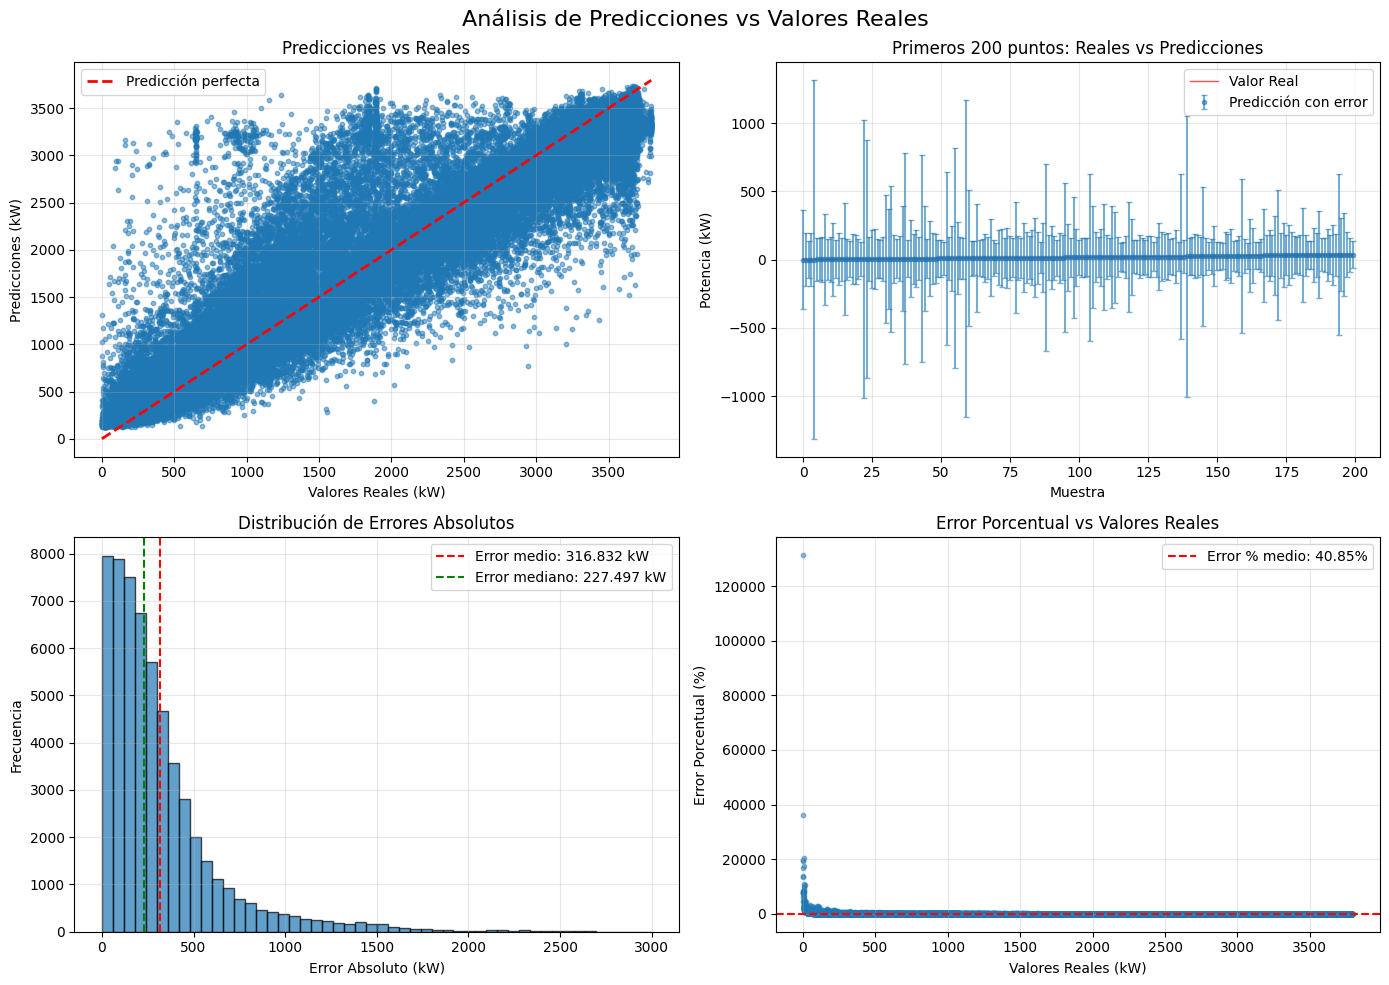


=== MÉTRICAS DE ERROR ===
MAE (Error Absoluto Medio): 316.8323 kW
RMSE: 452.8988 kW
MAPE (Error Porcentual Absoluto Medio): 40.85%
R²: 0.8561


In [60]:
plot_compare_test_pred(y_test_clean, y_pred_clean)

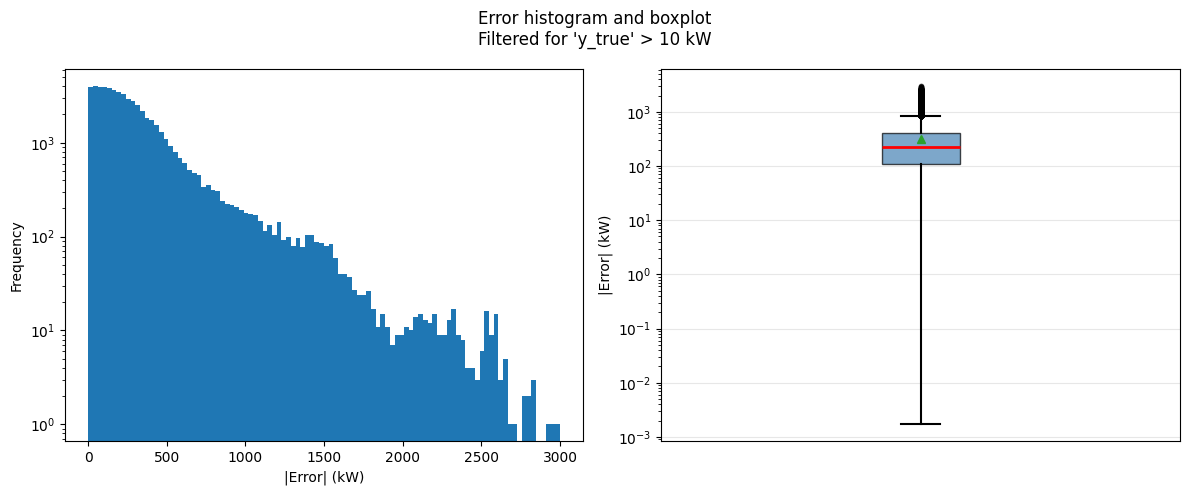

In [61]:
plot_hist_and_boxplot_error(y_test_clean, y_pred_clean)

## Check some conitnuous dates (e.g. whole April)

In [62]:
df_april_2024_curated_full = pd.read_csv("dataset/pvdt_9068_2024_04_curated_full.csv")

from scripts.proccess_previous_to_model import *
df_april_2024_to_fit_all_fields = proccess_previous_to_model_fit(df_april_2024_curated_full)

y_true = df_april_2024_to_fit_all_fields[TARGET]
df_april_2024_to_fit = get_df_for_model(df_april_2024_to_fit_all_fields)

In [63]:
# Z-scaler with previous scaler
df_april_2024_to_fit_norm, _ = apply_scaler(df_april_2024_to_fit, scaler=scaler, columns_to_scale=features)

In [64]:
# Filter cols
df_april_2024_to_fit_norm = get_df_for_model(df_april_2024_to_fit_norm)

# Reorder columns to match PCA model's expected order
df_april_2024_to_fit_norm = df_april_2024_to_fit_norm[model_pca.feature_names_in_]

# PCA
df_april_2024_to_fit_norm_pca = model_pca.transform(df_april_2024_to_fit_norm)

# ❗ Apply ANN-model
y_pred = model_ann.predict(df_april_2024_to_fit_norm_pca)
y_pred = y_pred.flatten()

# PolyFit did not learn about POA = 0
if True:
    # Set 0.0 if low irradiance (model trained with no night data: training CSVs)
    # Here not needed cause X_test came from those training CSVs
    MIN_POA_WM2 = 50
    mask_low_POA = df_april_2024_to_fit_all_fields["poa_irradiance_wm2"] < MIN_POA_WM2
    y_pred[mask_low_POA] = 0.0

# Evitamos predicciones negativas por seguridad física.
y_pred = np.clip(y_pred, 0, None)

201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step


Estadísticas para predicciones con irradiance mayor a 50 W/m2
desde 2024-04-08 09:35:00
hasta 2024-04-30 23:55:00
	Error absoluto medio:   401.021 kW
	Error porcentual medio: 149361522.67%
	Desv. estándar error:   309.578 kW
	Percentil 95 error:     1072.787 kW


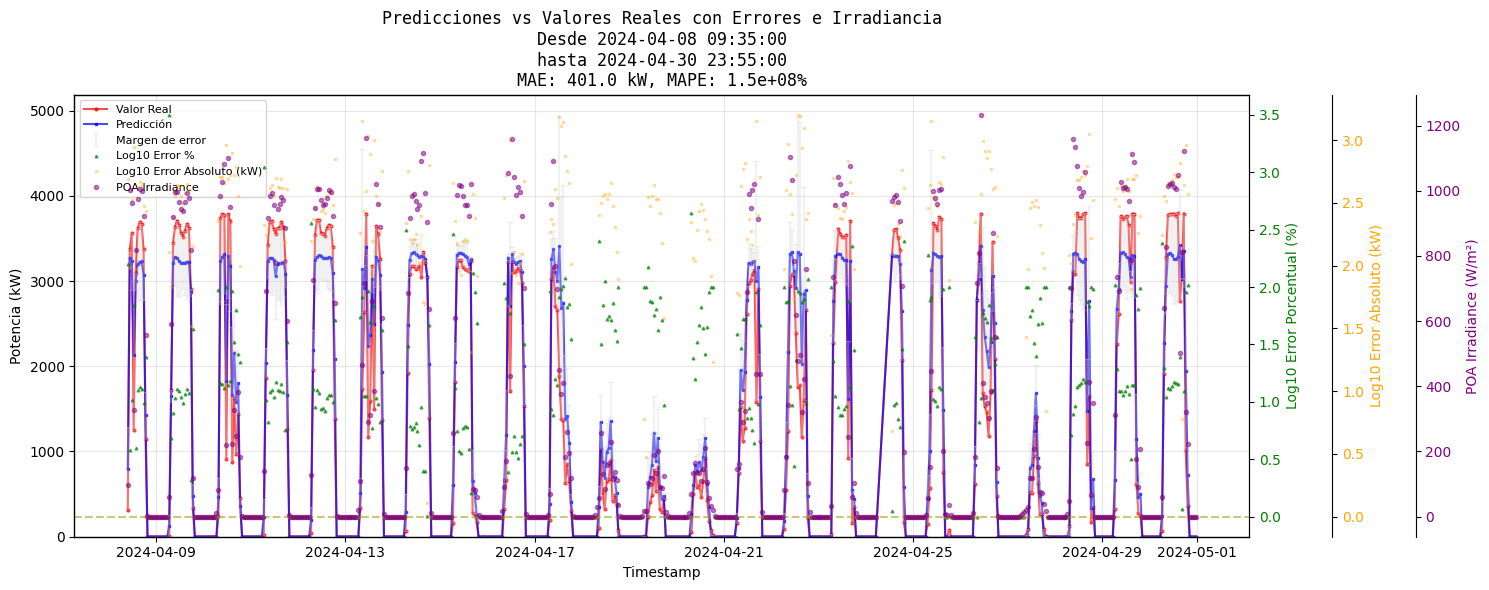

In [65]:
plot_df_pred_true(df_april_2024_to_fit_all_fields, y_true, y_pred);

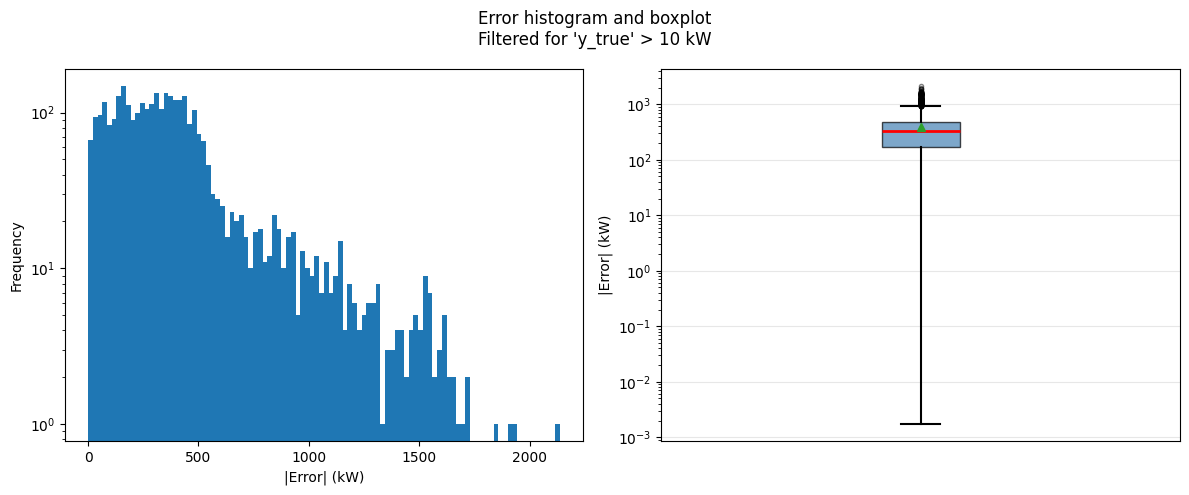

In [66]:
plot_hist_and_boxplot_error(y_true, y_pred)

## Store Model

In [67]:
import pickle

# Guardar el modelo
with open('models/ann_model.pkl', 'wb') as file:
    pickle.dump(model_ann, file)

## Results

Why Random Forest likely outperforms ANN here:

### 1. **Tabular data with PCA features** (5 dimensions)
- **Random Forest** excels at tabular data, especially with low-dimensional inputs
- **Neural networks** typically need more features (hundreds+) to shine - they're overparameterized for just 5 inputs
- Your `[256, 128, 64]` network has **~50,000+ parameters** but only 5 inputs - that's massive overparameterization!

### 2. **Data size matters**
- You're tuning on ~55k samples, which is decent but not huge
- Random Forest handles this size efficiently without overfitting
- Your ANN architecture is likely memorizing patterns rather than generalizing

### 3. **Non-linear interactions**
- Random Forest naturally captures complex interactions and non-linearities
- With only 5 PCA features, the decision boundaries are likely tree-like (piecewise constant)
- Neural networks need more data to learn smooth non-linear boundaries effectively

### 4. **What's your Random Forest R²?**
You mentioned it's "better" - what's the actual score? If it's >0.88-0.90, that confirms RF is the better choice here.